In [2]:
pip install scikit-learn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd      # For handling data in tabular form (DataFrames)
import numpy as np       # For numerical operations and arrays
from sklearn import linear_model  # For linear models like LinearRegression, LogisticRegression, etc.
import matplotlib.pyplot as plt   # For data visualization and plotting


In [4]:
df=pd.read_csv('area_price_csv.csv')
df

    


,Area,Price
0,2600,550000
1,3000,565000
2,3200,610000
3,3600,680000
4,4000,725000


In [5]:
df.Price

0    550000
1    565000
2    610000
3    680000
4    725000
Name: Price, dtype: int64

In [6]:
import pandas as pd      # For handling data in tabular form (DataFrames)
import numpy as np       # For numerical operations and arrays
from sklearn import linear_model  # For linear models like LinearRegression, LogisticRegression, etc.
import matplotlib.pyplot as plt 
df=pd.read_csv('linear.csv')
df

,area,price
0,2600,550000
1,3000,565000
2,3200,610000
3,3600,680000
4,4000,725000


In [7]:
df.area

0    2600
1    3000
2    3200
3    3600
4    4000
Name: area, dtype: int64

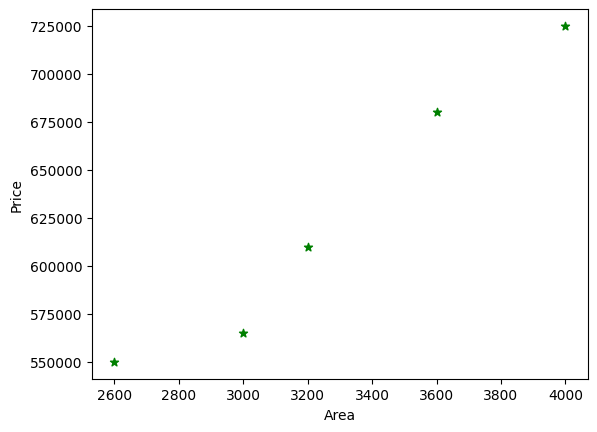

In [8]:
%matplotlib inline
plt.xlabel('Area')
plt.ylabel('Price')
plt.scatter(df.area,df.price,color='green',marker="*")

In [9]:
x = df.drop('price', axis=1)
x

,area
0,2600
1,3000
2,3200
3,3600
4,4000


In [10]:
y=df.price
y

0    550000
1    565000
2    610000
3    680000
4    725000
Name: price, dtype: int64

In [11]:
from sklearn.linear_model import LinearRegression

In [12]:
#create linear regression object
from sklearn import linear_model

model = linear_model.LinearRegression()


In [13]:
model.fit(x,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [14]:
#predict price of a home with area=3300sqrft
model.predict([[3300]])

C:\Users\eurov\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([628715.75342466])

In [15]:
model.coef_

array([135.78767123])

In [16]:
model.intercept_

np.float64(180616.43835616432)

In [17]:
#y=m*X+b(m is coefficient and b is intercept)
3300*135.78767123+180616.43835616432

628715.7534151643

In [18]:
#predict price of a home with area=5000 sqrft
model.predict([[5000]])

C:\Users\eurov\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([859554.79452055])

In [19]:
#we can predict predictions with more than one buildings.
#Generate csv file with list of home price predictions.
area_df=pd.read_csv("home.csv")
area_df

,area
0,1000
1,1500
2,2300
3,3540
4,4120
5,4560
6,5490
7,3460
8,4750
9,2300


In [20]:
p=model.predict(area_df)
p

array([ 316404.10958904,  384297.94520548,  492928.08219178,
        661304.79452055,  740061.64383562,  799808.21917808,
        926090.75342466,  650441.78082192,  825607.87671233,
        492928.08219178, 1402705.47945205, 1348390.4109589 ,
       1144708.90410959])

In [21]:
area_df['prices']=p
area_df

,area,prices
0,1000,3.164041e+05
1,1500,3.842979e+05
2,2300,4.929281e+05
3,3540,6.613048e+05
4,4120,7.400616e+05
5,4560,7.998082e+05
6,5490,9.260908e+05
7,3460,6.504418e+05
8,4750,8.256079e+05
9,2300,4.929281e+05


In [22]:
area_df.to_csv("predic.csv")

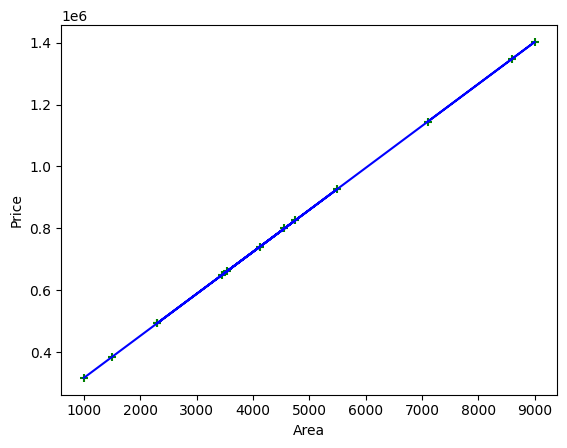

In [23]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.xlabel('Area')
plt.ylabel('Price')

# Scatter plot for actual data
plt.scatter(area_df.area, area_df.prices, color='green', marker='+')

# Plot predicted line
plt.plot(area_df.area, model.predict(area_df[['area']]), color='blue')



In [24]:
#Linear Regression multiple variables.

In [25]:
import pandas as pd
from sklearn import linear_model
df=pd.read_csv('home_price.csv')
df

,area,bedrooms,age,price
0,2600,3.0,20,550000
1,3000,4.0,15,565000
2,3200,NaN,18,610000
3,3600,3.0,30,595000
4,4000,5.0,8,760000
5,4100,6.0,8,810000


In [26]:
#Data preprocessing:fill NA values with median value of a column.

In [27]:
df.bedrooms.median()

np.float64(4.0)

In [28]:
df.bedrooms=df.bedrooms.fillna(df.bedrooms.median())
df

,area,bedrooms,age,price
0,2600,3.0,20,550000
1,3000,4.0,15,565000
2,3200,4.0,18,610000
3,3600,3.0,30,595000
4,4000,5.0,8,760000
5,4100,6.0,8,810000


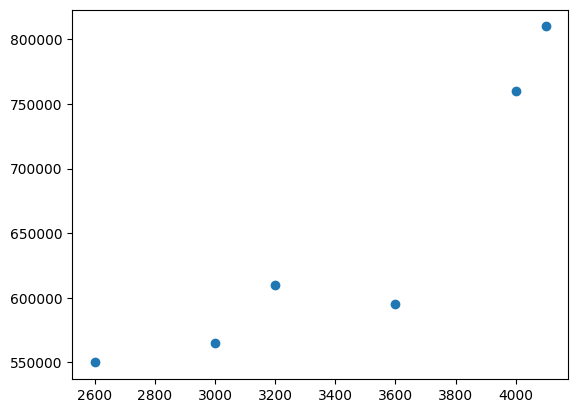

In [29]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.scatter(df.area,df.price)
#plt.scatter(df.bedrooms,df.price)
#plt.scatter(df.age,df.price)

In [30]:
df1=df.drop('price',axis='columns')
df1

,area,bedrooms,age
0,2600,3.0,20
1,3000,4.0,15
2,3200,4.0,18
3,3600,3.0,30
4,4000,5.0,8
5,4100,6.0,8


In [31]:
reg=linear_model.LinearRegression()
reg.fit(df.drop('price',axis='columns'),df.price)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [32]:
reg.predict([[3000,3,40]])

C:\Users\eurov\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([498408.25158031])

In [33]:
reg.coef_

array([  112.06244194, 23388.88007794, -3231.71790863])

In [34]:
reg.intercept_

np.float64(221323.0018654043)

In [35]:
#find price of home with 3000 sqrt area,3 bedrooms,40 years old.
reg.predict([[3000,3,40]])

C:\Users\eurov\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([498408.25158031])

In [36]:
112.06244194*3000 + 23388.88007794*3 + -3231.71790863*40 + 221323.00186540384

498408.25157402386

In [37]:
#find price of home with 2500 sqrft area,4 bedrooms,5 years old

In [38]:
reg.predict([[2500,4,5]])

C:\Users\eurov\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([578876.03748933])

In [39]:
import statistics as stats

data1 = [ 10, 10, 20, 30, 40, 20, 30]
print("Mode:", stats.mode(data1))

Mode: 10


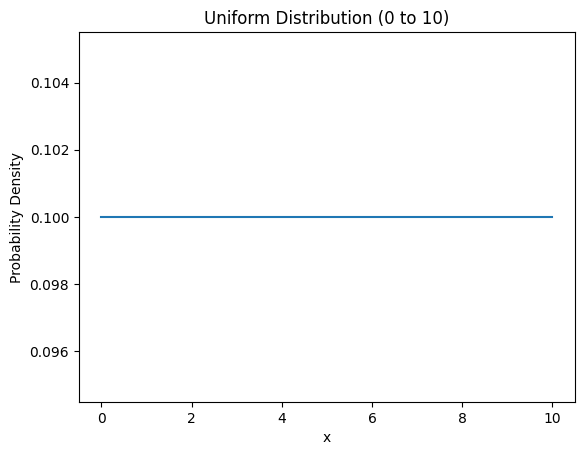

In [40]:
from scipy.stats import uniform
import numpy as np
import matplotlib.pyplot as plt

a, b = 0, 10  # range
x = np.linspace(a, b, 100)
y = uniform.pdf(x, a, b - a)

plt.plot(x, y)
plt.title("Uniform Distribution (0 to 10)")
plt.xlabel("x")
plt.ylabel("Probability Density")
plt.show()


In [41]:
#lOGISTIC REGRESSION BINARY CLASSIFICATION

In [42]:
import pandas as pd
from matplotlib import pyplot as plt
%matplotlib inline
df=pd.read_csv("3-10insurance_data.csv")
df

,age,bought_insurance
0,22,0
1,25,0
2,47,1
3,52,0
4,46,1
5,56,1
6,55,0
7,60,1
8,62,1
9,61,1


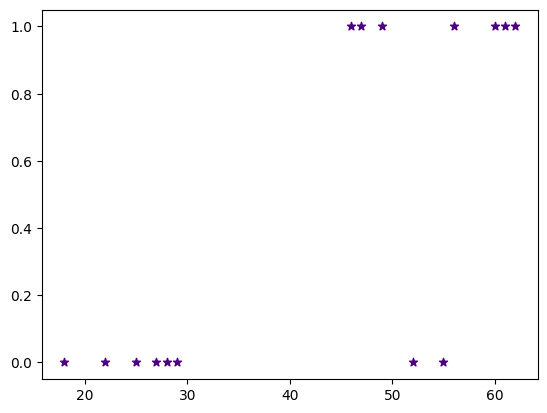

In [43]:
plt.scatter(df.age,df.bought_insurance,marker='*',color="indigo")

In [44]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    df[['age']], df['bought_insurance'], train_size=0.9
)
x_test

,age
0,22
13,29


In [45]:
import pandas as pd
import numpy as np
from sklearn import linear_model
df=pd.read_csv("linear.csv")
df

,area,price
0,2600,550000
1,3000,565000
2,3200,610000
3,3600,680000
4,4000,725000


In [46]:
#create linear regression object
from sklearn import linear_model

model = linear_model.LinearRegression()


In [47]:
model.fit(df[['area']],df.price)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [48]:
model.coef_


array([135.78767123])

In [49]:
model.intercept_

np.float64(180616.43835616432)

In [50]:
model.predict([[5000]])

C:\Users\eurov\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([859554.79452055])

In [51]:
import pickle

In [52]:
with open('model_pickle','wb')as file:
    pickle.dump(model,file)

In [53]:
with open('model_pickle','rb')as file:
  mp=pickle.load(file)

In [54]:
mp.coef_

array([135.78767123])

In [55]:
mp.intercept_

np.float64(180616.43835616432)

In [56]:
mp.predict([[50000]])

C:\Users\eurov\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([6970000.])

In [57]:
import pandas as pd
df=pd.read_csv('rqh.csv')
df

,town,area,price
0,monroe township,2600,550000
1,monroe township,3000,565000
2,monroe township,3200,610000
3,monroe township,3600,680000
4,monroe township,4000,725000
5,west windsor,2600,585000
6,west windsor,2800,615000
7,west windsor,3300,650000
8,west windsor,3600,710000
9,robinsvilla,2600,575000


In [58]:
dummies=pd.get_dummies(df.town,dtype=int)
dummies

,monroe township,robinsvilla,west windsor
0,1,0,0
1,1,0,0
2,1,0,0
3,1,0,0
4,1,0,0
5,0,0,1
6,0,0,1
7,0,0,1
8,0,0,1
9,0,1,0


In [59]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Example dataset
data = {
    'age': [22, 25, 47, 52, 46, 56, 55, 60],
    'salary': [20000, 25000, 50000, 52000, 49000, 60000, 58000, 62000],
    'bought_insurance': [0, 0, 1, 1, 1, 1, 1, 1]
}
df = pd.DataFrame(data)

# Features and target
X = df[['age', 'salary']]
y = df['bought_insurance']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=1
)

print("Training Data:")
print(X_train)
print("\nTesting Data:")
print(X_test)


Training Data:
   age  salary
1   25   25000
6   55   58000
0   22   20000
4   46   49000
3   52   52000
5   56   60000

Testing Data:
   age  salary
7   60   62000
2   47   50000


In [60]:
#Logistic regression with multinomial

In [63]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import seaborn as sns
# Load dataset
data=sns.load_dataset('iris')

In [64]:
data


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [65]:
data['species'].unique()

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [66]:
data['species'].replace({'setosa':'1','versicolor':'2','virginica':'3'},inplace=True)

C:\Users\eurov\AppData\Local\Temp\ipykernel_68568\233542239.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['species'].replace({'setosa':'1','versicolor':'2','virginica':'3'},inplace=True)


In [75]:
data

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,1
2,4.7,3.2,1.3,0.2,1
3,4.6,3.1,1.5,0.2,1
4,5.0,3.6,1.4,0.2,1
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,3
146,6.3,2.5,5.0,1.9,3
147,6.5,3.0,5.2,2.0,3
148,6.2,3.4,5.4,2.3,3


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    data[['sepal_length','sepal_width','petal_length','petal_width']],
    data['species'],
    test_size=0.2
)


In [76]:
len(X_train)



6

In [68]:
len(X_test)

2

In [69]:
from sklearn.linear_model import LogisticRegression

In [70]:
lr=LogisticRegression()

In [71]:
lr.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [77]:
lr.predict(X_test)

array([1, 1])

In [78]:
X_test                        #'setosa':'1','versicolor':'2','virginica':'3'

,age,salary
7,60,62000
2,47,50000


In [79]:
lr.score(X_test,y_test)


1.0

In [74]:
import seaborn as sns

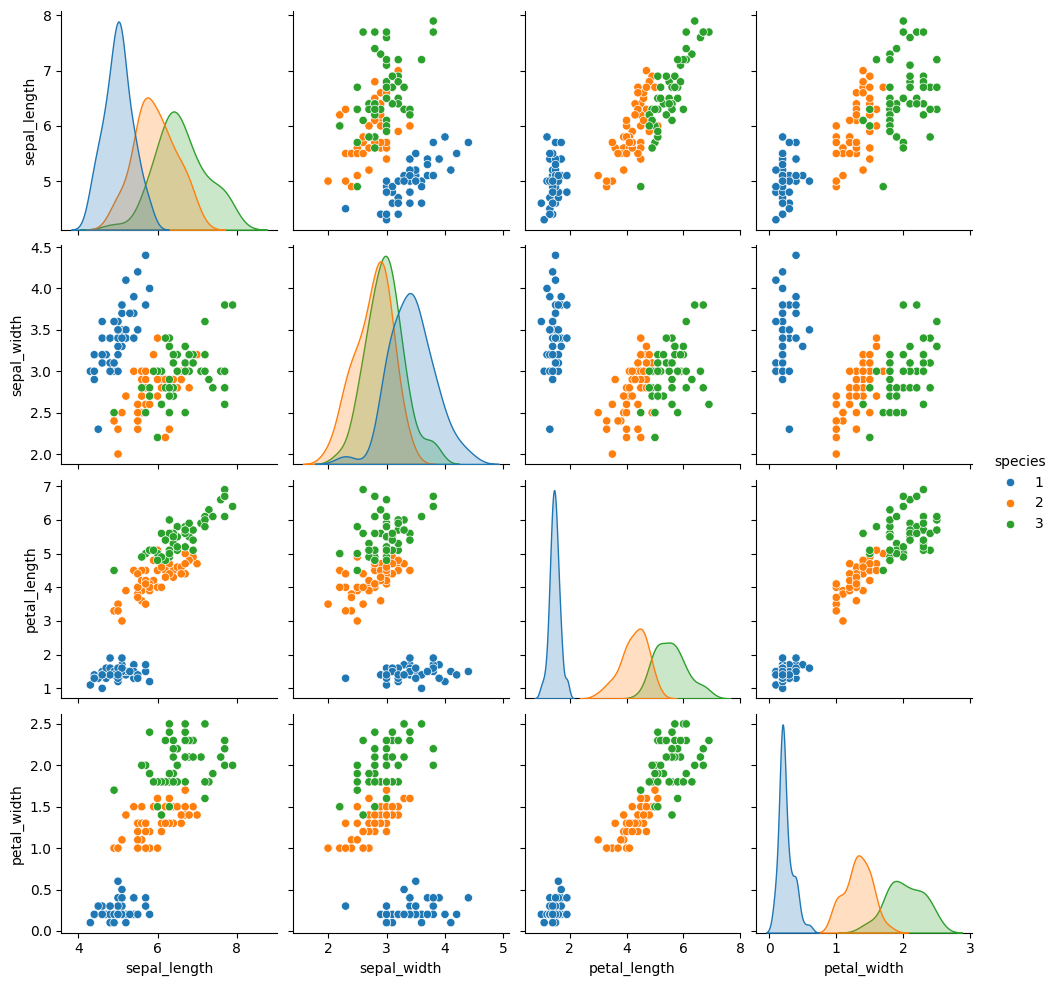

In [35]:
sns.pairplot(data[['sepal_length','sepal_width','petal_length','petal_width',	'species']],hue='species')

In [1]:
#decision tree


In [2]:
import pandas as pd


In [3]:
data=pd.read_csv("tennis.csv")

In [4]:
data

,outlook,humidity,windy,play
0,sunny,high,weak,no
1,sunny,high,strong,no
2,overcast,high,weak,yes
3,rainy,high,weak,yes
4,rainy,normal,weak,yes


In [5]:
from sklearn.preprocessing import LabelEncoder

In [6]:
outlook=LabelEncoder()
humidity=LabelEncoder()
windy=LabelEncoder()
play=LabelEncoder()

In [7]:
data['outlook']=outlook.fit_transform(data['outlook'])
data['humidity']=humidity.fit_transform(data['humidity'])
data['windy']=windy.fit_transform(data['windy'])
data['play']=play.fit_transform(data['play'])
data

,outlook,humidity,windy,play
0,2,0,1,0
1,2,0,0,0
2,0,0,1,1
3,1,0,1,1
4,1,1,1,1


In [8]:
feature_cols=['outlook','humidity','windy']
x=data[feature_cols]


In [9]:
x

,outlook,humidity,windy
0,2,0,1
1,2,0,0
2,0,0,1
3,1,0,1
4,1,1,1


In [10]:
y=data.play
y

0    0
1    0
2    1
3    1
4    1
Name: play, dtype: int64

In [1]:
# Random forest Algorithm

In [2]:
from sklearn import datasets

In [6]:
iris=datasets.load_iris()
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [4]:
print(iris.target_names)

['setosa' 'versicolor' 'virginica']


In [5]:
print(iris.feature_names)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [1]:
import pandas as pd
pd.DataFrame({'sepal length':iris.data[:0]})

NameError: name 'iris' is not defined

In [9]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

data = load_diabetes()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = RandomForestClassifier(n_estimators=100,criterion='gini', random_state=42)
model.fit(X_train, y_train)

score = model.score(X_test, y_test)
print("Model Score:", score)



C:\Users\eurov\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\multiclass.py:213: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  y_type = type_of_target(y, input_name="y")
C:\Users\eurov\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\multiclass.py:213: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  y_type = type_of_target(y, input_name="y")
C:\Users\eurov\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\multiclass.py:213: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  y_type = type_of_target(y, input_name="y")
C:\Users\eurov\AppData\Local\Programs\Python\Python313\Lib\site-pac

Model Score: 0.007518796992481203


C:\Users\eurov\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
C:\Users\eurov\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")


In [3]:
X = data.data
X

array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
         0.01990749, -0.01764613],
       [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
        -0.06833155, -0.09220405],
       [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
         0.00286131, -0.02593034],
       ...,
       [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
        -0.04688253,  0.01549073],
       [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
         0.04452873, -0.02593034],
       [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
        -0.00422151,  0.00306441]], shape=(442, 10))

In [1]:
from skimage.feature import hog
from skimage import io, color
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
import numpy as np
import os

# ----------------------------
# Load dataset
# ----------------------------

def load_images(folder):
    images = []
    for filename in os.listdir(folder):
        img = io.imread(os.path.join(folder, filename))
        img = color.rgb2gray(img)
        img = np.resize(img, (128, 128))   # resize image
        images.append(img)
    return images

positive_images = load_images("faces/")          # folder of face images
negative_images = load_images("non_faces/")      # folder of non-face images

# ----------------------------
# Extract HOG features
# ----------------------------

def extract_hog_features(images):
    hog_features = []
    for img in images:
        features = hog(img, pixels_per_cell=(8, 8), cells_per_block=(2, 2))
        hog_features.append(features)
    return hog_features

X_pos = extract_hog_features(positive_images)
X_neg = extract_hog_features(negative_images)

# Labels
y_pos = [1] * len(X_pos)
y_neg = [0] * len(X_neg)

# Convert to numpy
X = np.array(X_pos + X_neg)
y = np.array(y_pos + y_neg)

# ----------------------------
# Train SVM model
# ----------------------------

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
model = LinearSVC()
model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))


ModuleNotFoundError: No module named 'skimage'

In [ ]:
pip install scikit-image

In [4]:
from skimage.feature import hog
from skimage import io, color
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
import numpy as np
import os

# ----------------------------
# Load dataset
# ----------------------------

def load_images(folder):
    images = []
    for filename in os.listdir(folder):
        img = io.imread(os.path.join(folder, filename))
        img = color.rgb2gray(img)
        img = np.resize(img, (128, 128))   # resize image
        images.append(img)
    return images

positive_images = load_images("faces/")          # folder of face images
negative_images = load_images("non_faces/")      # folder of non-face images

# ----------------------------
# Extract HOG features
# ----------------------------

def extract_hog_features(images):
    hog_features = []
    for img in images:
        features = hog(img, pixels_per_cell=(8, 8), cells_per_block=(2, 2))
        hog_features.append(features)
    return hog_features

X_pos = extract_hog_features(positive_images)
X_neg = extract_hog_features(negative_images)

# Labels
y_pos = [1] * len(X_pos)
y_neg = [0] * len(X_neg)

# Convert to numpy
X = np.array(X_pos + X_neg)
y = np.array(y_pos + y_neg)

# ----------------------------
# Train SVM model
# ----------------------------

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
model = LinearSVC()
model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))


FileNotFoundError: [WinError 3] The system cannot find the path specified: 'faces/'